# 월간 데이콘 심리 성향 예측 — 투표 안 한 확률 예측
- **타겟**: voted=1(투표 안 함) 확률
- **평가**: AUC, Accuracy
- **모델**: LightGBM + XGBoost + CatBoost (Soft Voting 앙상블)
- **검증**: Stratified 5-Fold OOF

## 0. 라이브러리

In [1]:
pip install koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import koreanize_matplotlib
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
try:
    plt.rcParams['font.family'] = 'NanumGothic'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

SEED = 42
N_FOLDS = 5
np.random.seed(SEED)
print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로드

In [3]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test_x.csv')
sub   = pd.read_csv('sample_submission.csv')

print('Train:', train.shape)
print('Test :', test.shape)

# voted: 1=투표 안 함, 2=투표 함
# 타겟 = 투표 안 한 확률 → y=1 이 '투표 안 함'
print('\n타겟 분포:')
print(train['voted'].value_counts())
print('  1=투표안함, 2=투표함')

Train: (45532, 78)
Test : (11383, 77)

타겟 분포:
voted
2    24898
1    20634
Name: count, dtype: int64
  1=투표안함, 2=투표함


## 2. 피처 엔지니어링

In [4]:
X = train.drop(columns=['voted'])
y = train['voted']
# 범주형 자동 변환
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category').cat.codes

# 모델 학습
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)

# 중요도 추출
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

# 상위 20개 확인
print(importances.head(20))

      feature  importance
41  age_group    0.079479
42  education    0.056257
47    married    0.023797
0       index    0.023673
2         QaE    0.023448
14        QgE    0.023430
38        QsE    0.023339
10        QeE    0.023280
28        QnE    0.023278
26        QmE    0.023098
22        QkE    0.023065
20        QjE    0.023064
34        QqE    0.023062
36        QrE    0.023061
30        QoE    0.023060
16        QhE    0.023025
4         QbE    0.023017
40        QtE    0.022974
18        QiE    0.022946
12        QfE    0.022934


In [5]:
train = train.drop(columns=['index'])
test  = test.drop(columns=['index'])
# index 제거 과적합 방지



In [25]:
def build_features(df):
    df = df.copy()

    # ── QA 수치 변환
    qa_cols = [f'Q{chr(97+i)}A' for i in range(20)] # 문자열은 숫자로 변환
    for c in qa_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(3) # 이상값은 중립값 3으로 채움

    # ── MACH-IV 역채점 (QcA, QfA, QiA, QkA, QlA, QqA) 1~5 척도에서 부정 문항 뒤집기(점수 방향 통일)
    reverse_mach = ['QcA','QfA','QiA','QkA','QlA','QqA']
    for c in reverse_mach:
        df[c] = 6 - df[c]

    # MACH-IV 하위척도  Machiavellian 성향을 3개로 나눔
    tactics  = ['QaA','QbA','QdA','QeA','QhA','QjA','QmA','QoA','QpA','QsA','QtA']  # 전략적 행동
    views    = ['QcA','QgA','QiA','QnA','QrA']# 사람에 대한 관점
    morality = ['QfA','QkA','QlA','QqA']    # 도덕성
    #  각 그룹 평균이 성향 점수가 됨
    df['mach_tactics']  = df[tactics].mean(axis=1)  
    df['mach_views']    = df[views].mean(axis=1)
    df['mach_morality'] = df[morality].mean(axis=1)
    df['mach_total']    = df[qa_cols].mean(axis=1)  # 전체 평균 = 전체 마키아벨리즘 점수

    # ── TIPI Big Five 역채점 
    reverse_tipi = ['tp02','tp06','tp08','tp09','tp10']
    for c in reverse_tipi:
        df[c] = 8 - df[c].astype(float) # 1~7 척도 뒤집어서 점수 방향 맞추기
    df['big5_E'] = (df['tp01'] + df['tp06']) / 2  # 외향성
    df['big5_A'] = (df['tp07'] + df['tp02']) / 2  # 친화성
    df['big5_C'] = (df['tp03'] + df['tp08']) / 2  # 성실성 ★
    df['big5_N'] = (df['tp04'] + df['tp09']) / 2  # 신경성
    df['big5_O'] = (df['tp05'] + df['tp10']) / 2  # 개방성

    # ── QE 응답시간 피처
    qe_cols = [f'Q{chr(97+i)}E' for i in range(20)]
    qe = df[qe_cols].astype(float).clip(upper=60_000)   # 응답 시간 이상치 제거 (최대 60초)
    df['qe_mean']    = np.log1p(qe.mean(axis=1))    # 평균 응답시간 (로그 변환)
    df['qe_std']     = qe.std(axis=1)             # 핵심 신호 (응답 시간의 흔들림 -> 고민 클수록 분산 커짐)
    df['qe_cv']      = df['qe_std'] / (qe.mean(axis=1) + 1e-6)  #상대적인 변동성
    df['qe_max']     = np.log1p(qe.max(axis=1)) # 가장 오래 고민한 문항

    # 망설임 지수 중립(3)에 가까울수록 고민 많음 , 시간 오래 + 중립 답변 -> 우유부단
    qa_arr = df[qa_cols].values
    df['hesitation'] = (qe.values / (np.abs(qa_arr - 3) + 1)).mean(axis=1)

    # ── wr / wf 관련 문항 합계  (특정 행동 패턴 요약)
    wr_cols = [f'wr_{i:02d}' for i in range(1, 14)]
    df['wr_sum'] = df[wr_cols].sum(axis=1)
    df['wf_sum'] = df[['wf_01','wf_02','wf_03']].sum(axis=1)

    # ── 교차 피처 -  단일 변수보다 더 강한 신호 생성
    df['C_x_tactics']  = df['big5_C'] * df['mach_tactics']  # 성격 + 행동 결합
    df['N_x_morality'] = df['big5_N'] * df['mach_morality']
    df['A_x_views']    = df['big5_A'] * df['mach_views']

    # ── familysize 이상치 (가족 수가 너무 큰 값 제한)
    df['familysize'] = df['familysize'].clip(upper=20)

    # ── 피처 중요도 결과 기반 추가
    # ── age 순서형 인코딩 먼저
    age_order = {'10s': 0, '20s': 1, '30s': 2, '40s': 3,
                    '50s': 4, '60s': 5, '+70s': 6}
    df['age_ord'] = df['age_group'].map(age_order).fillna(3).astype(float)
    df['age_sq'] = df['age_ord'] ** 2    # age_sq: 연령의 비선형 효과 (고령일수록 투표율 급증)

    # ── education / married 숫자화
    if 'education' in df.columns:
        df['education'] = pd.to_numeric(df['education'], errors='coerce')
        df['education'] = df['education'].fillna(df['education'].median())

        df['edu_sq'] = df['education'] ** 2

    if 'married' in df.columns:
        df['married'] = pd.to_numeric(df['married'], errors='coerce').fillna(0)

        df['age_x_married'] = df['age_ord'] * df['married']

    if 'education' in df.columns and 'married' in df.columns:
        df['edu_x_married'] = df['education'] * df['married']
    
    # age × education 교호작용 (학력과 연령의 복합 효과)
    if 'education' in df.columns:
        edu = pd.to_numeric(df['education'], errors='coerce')
        edu = edu.fillna(edu.median())
        df['age_x_edu'] = df['age_ord'] * edu

    # age × married 교호작용 (결혼 여부와 연령의 복합 효과)
    if 'married' in df.columns:
        mar = pd.to_numeric(df['married'], errors='coerce').fillna(0)
        df['age_x_married'] = df['age_ord'] * mar

    # age × big5_C 교호작용 (성실성은 연령과 시너지)
    df['age_x_C'] = df['age_ord'] * df['big5_C']

    # age × mach_total 교호작용
    df['age_x_mach'] = df['age_ord'] * df['mach_total']
    return df



train = build_features(train)
test  = build_features(test)
print('피처 엔지니어링 완료')
print('Train 컬럼 수:', train.shape[1])




피처 엔지니어링 완료
Train 컬럼 수: 110


## 3. 전처리

In [26]:
# voted: 1=투표안함(양성), 2=투표함(음성) → y=1이 '투표 안 함'
y = (train['voted'] == 1).astype(int).values
print('타겟(투표안함=1) 비율:', y.mean().round(4))
#  race / religion / age_group: 그룹별 투표율 차이 타깃 인코딩 -> 단순 LabelEncoding 대비 훨씬 강한 신호
te_cols_cat = ['race', 'religion', 'age_group']

# TE 계산 전 원본 범주 문자열값 보존 (LabelEncoding 전에 저장)
te_src_train = train[te_cols_cat].astype(str).copy()
te_src_test  = test[te_cols_cat].astype(str).copy()

def make_te_map(cat_series, y_series, smoothing=10):
    """
    스무딩 타깃 인코딩 맵 생성
    smoothed = (count × mean + smoothing × global_mean) / (count + smoothing)
    소수 그룹의 불안정한 추정값을 전체 평균 쪽으로 당김
    """
    gm = float(y_series.mean())
    tmp = pd.DataFrame({'cat': cat_series.values, 'y': y_series.values})
    stats = tmp.groupby('cat')['y'].agg(['mean', 'count'])
    smoothed = (stats['count'] * stats['mean'] + smoothing * gm) / (stats['count'] + smoothing)
    return smoothed.to_dict(), gm

# 전체 train 기준 TE 맵 (test 적용 + CV 루프 내 train fold 적용하기 위함)
te_maps_full = {}
for tc in te_cols_cat:
    te_map, gm = make_te_map(te_src_train[tc], pd.Series(y))
    te_maps_full[tc] = (te_map, gm)

# TE 플레이스홀더 컬럼 추가
#  - train: OOF 방식으로 CV 루프에서 채워짐 (일단 0으로 초기화)
#  - test : 전체 train 기준 TE 즉시 적용
for tc in te_cols_cat:
    te_map, gm = te_maps_full[tc]
    train[tc + '_te'] = 0.0                                          # CV 루프에서 OOF 갱신
    test[tc + '_te']  = te_src_test[tc].map(te_map).fillna(gm)      # 전체 train 기준 적용

# ── 일반 레이블 인코딩 (age_group, gender, race, religion)
#    tree 모델을 위한 정수 인코딩 (TE와 병렬로 사용)
cat_cols = ['age_group', 'gender', 'race', 'religion']
for c in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[c], test[c]], axis=0).astype(str)
    le.fit(combined)
    train[c] = le.transform(train[c].astype(str))
    test[c]  = le.transform(test[c].astype(str))

# 피처 선택 (index, voted 제외)
drop_cols = ['index','voted']
feat_cols = [c for c in train.columns if c not in drop_cols]

X      = train[feat_cols].astype(float)
X_test = test[feat_cols].astype(float)

print('피처 수:', len(feat_cols))
print('결측값:', X.isnull().sum().sum())

타겟(투표안함=1) 비율: 0.4532
피처 수: 109
결측값: 0


## 4. 모델 학습 — Stratified 5-Fold OOF

In [27]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# OOF / 테스트 예측 저장
oof_lgb = np.zeros(len(y))
oof_xgb = np.zeros(len(y))
oof_cat = np.zeros(len(y))

test_lgb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))
test_cat = np.zeros(len(X_test))

# ── LightGBM 파라미터
lgb_params = dict(
    objective='binary', metric='auc',
    n_estimators=1000, learning_rate=0.05,
    num_leaves=63, max_depth=-1,
    min_child_samples=20, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.0, random_state=SEED,
    verbose=-1, n_jobs=-1
)

# ── XGBoost 파라미터
xgb_params = dict(
    objective='binary:logistic', eval_metric='auc',
    n_estimators=1000, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.0, random_state=SEED,
    verbosity=0, n_jobs=-1
)

# ── CatBoost 파라미터
cat_params = dict(
    iterations=1000, learning_rate=0.05,
    depth=6, l2_leaf_reg=3,
    random_seed=SEED, eval_metric='AUC',
    verbose=0
)

print('='*55)
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    # ── .copy()로 독립 복사 (TE 컬럼 수정을 위해 필수)
    X_tr = X.iloc[tr_idx].copy()    # fold 내 train 데이터로만 계산한 TE 적용
    X_va = X.iloc[va_idx].copy()    # 위와 동일한 맵으로 적용 
    X_te = X_test.copy()    # 전체 train 기준 TE (전처리 셀에서 이미 계산됨)
    y_tr, y_va = y[tr_idx], y[va_idx]

# OOF 타겟 인코딩(데이터 누수 방지)
    for tc in te_cols_cat:
        # fold train만 사용해 OOF TE 맵 생성
        te_map_oof, gm_oof = make_te_map(
            te_src_train.iloc[tr_idx][tc],
            pd.Series(y_tr)
        )
        # fold train & validation에 적용
        X_tr[tc + '_te'] = (te_src_train.iloc[tr_idx][tc]
                            .map(te_map_oof).fillna(gm_oof).values)
        X_va[tc + '_te'] = (te_src_train.iloc[va_idx][tc]
                            .map(te_map_oof).fillna(gm_oof).values)
        # X_te는 전처리 셀에서 이미 전체 train TE로 채워져 있으므로 그대로 사용
        
    # ── LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_params)
    m_lgb.fit(X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[lgb.early_stopping(50, verbose=False),
                            lgb.log_evaluation(-1)])
    oof_lgb[va_idx]  = m_lgb.predict_proba(X_va)[:, 1]
    test_lgb        += m_lgb.predict_proba(X_test)[:, 1] / N_FOLDS

    # ── XGBoost
    m_xgb = xgb.XGBClassifier(**xgb_params)
    m_xgb.fit(X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                verbose=False)
    oof_xgb[va_idx]  = m_xgb.predict_proba(X_va)[:, 1]
    test_xgb        += m_xgb.predict_proba(X_test)[:, 1] / N_FOLDS

    # ── CatBoost
    m_cat = CatBoostClassifier(**cat_params)
    m_cat.fit(X_tr, y_tr,
                eval_set=(X_va, y_va),
                early_stopping_rounds=50)
    oof_cat[va_idx]  = m_cat.predict_proba(X_va)[:, 1]
    test_cat        += m_cat.predict_proba(X_test)[:, 1] / N_FOLDS

    # Fold 결과
    auc_lgb = roc_auc_score(y_va, oof_lgb[va_idx])
    auc_xgb = roc_auc_score(y_va, oof_xgb[va_idx])
    auc_cat = roc_auc_score(y_va, oof_cat[va_idx])
    print(f'Fold {fold} | LGB {auc_lgb:.4f} | XGB {auc_xgb:.4f} | CAT {auc_cat:.4f}')

print('='*55)

Fold 1 | LGB 0.7800 | XGB 0.7679 | CAT 0.7807
Fold 2 | LGB 0.7694 | XGB 0.7567 | CAT 0.7701
Fold 3 | LGB 0.7622 | XGB 0.7536 | CAT 0.7630
Fold 4 | LGB 0.7607 | XGB 0.7506 | CAT 0.7632
Fold 5 | LGB 0.7686 | XGB 0.7582 | CAT 0.7686


## 5. 평가 지표 — AUC & Accuracy

In [28]:
# 앙상블 위 결과 기반 가중 평균으로 수정 캣부스트가 가장 잘나왔음
w_lgb, w_xgb, w_cat = 0.35, 0.15, 0.50

oof_ensemble  = w_lgb * oof_lgb + w_xgb * oof_xgb + w_cat * oof_cat
test_ensemble = w_lgb * test_lgb + w_xgb * test_xgb + w_cat * test_cat


# ── AUC
auc_lgb = roc_auc_score(y, oof_lgb)
auc_xgb = roc_auc_score(y, oof_xgb)
auc_cat = roc_auc_score(y, oof_cat)
auc_ens = roc_auc_score(y, oof_ensemble)

# ── Accuracy (threshold=0.5)
acc_lgb = accuracy_score(y, (oof_lgb  >= 0.5).astype(int))
acc_xgb = accuracy_score(y, (oof_xgb  >= 0.5).astype(int))
acc_cat = accuracy_score(y, (oof_cat  >= 0.5).astype(int))
acc_ens = accuracy_score(y, (oof_ensemble >= 0.5).astype(int))

result_df = pd.DataFrame({
    '모델':     ['LightGBM', 'XGBoost', 'CatBoost', '앙상블(가중평균)'],
    'OOF AUC':  [auc_lgb, auc_xgb, auc_cat, auc_ens],
    'Accuracy': [acc_lgb, acc_xgb, acc_cat, acc_ens],
}).set_index('모델')

print(result_df.round(4))
print(f"\n가중치: LGB={w_lgb}, XGB={w_xgb}, CAT={w_cat}")

           OOF AUC  Accuracy
모델                          
LightGBM    0.7678    0.6957
XGBoost     0.7574    0.6865
CatBoost    0.7690    0.6967
앙상블(가중평균)   0.7700    0.6959

가중치: LGB=0.35, XGB=0.15, CAT=0.5


## 6. 시각화

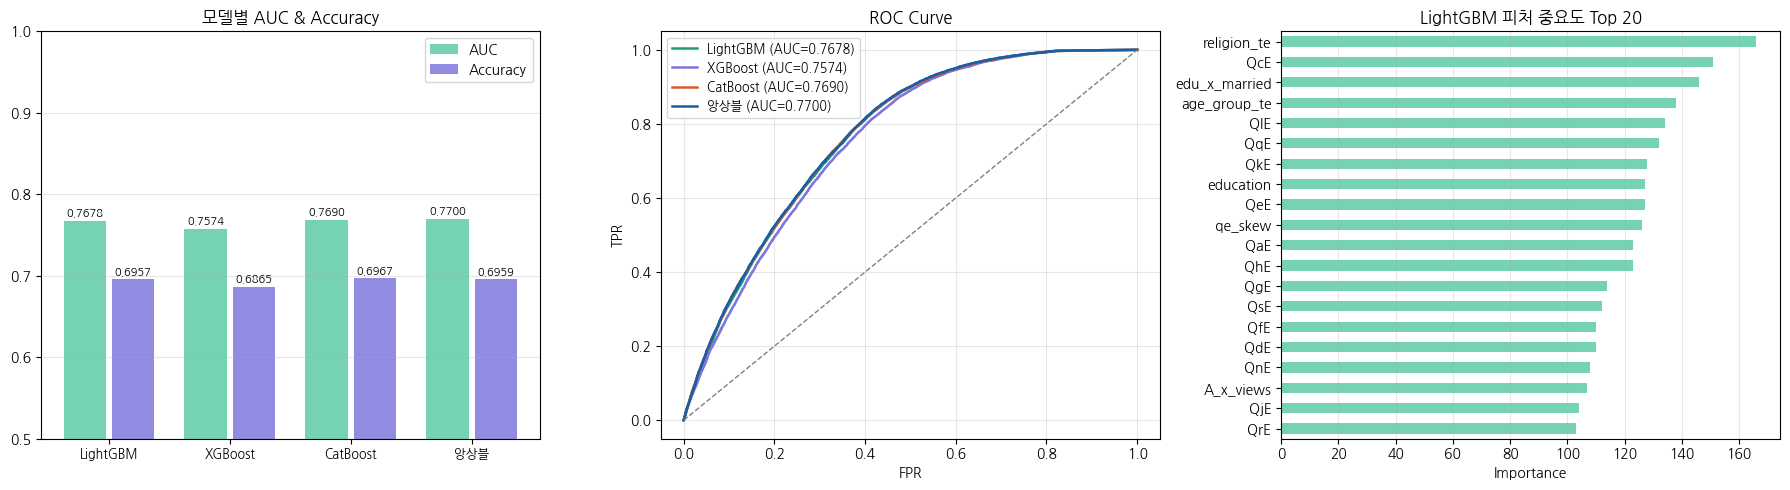

evaluation.png 저장 완료


In [29]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── (1) AUC / Accuracy 비교
ax = axes[0]
x = np.arange(4)
labels = ['LightGBM','XGBoost','CatBoost','앙상블']
aucs   = [auc_lgb, auc_xgb, auc_cat, auc_ens]
accs   = [acc_lgb, acc_xgb, acc_cat, acc_ens]
bars1 = ax.bar(x - 0.2, aucs, 0.35, label='AUC',      color='#5DCAA5', alpha=0.85)
bars2 = ax.bar(x + 0.2, accs, 0.35, label='Accuracy', color='#7F77DD', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0.5, 1.0); ax.set_title('모델별 AUC & Accuracy', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)
for b in bars1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for b in bars2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=8)

# ── (2) ROC Curve
ax = axes[1]
for preds, name, color in [
    (oof_lgb,      'LightGBM', '#1D9E75'),
    (oof_xgb,      'XGBoost',  '#7F77DD'),
    (oof_cat,      'CatBoost', '#D85A30'),
    (oof_ensemble, '앙상블',    '#185FA5'),
]:
    fpr, tpr, _ = roc_curve(y, preds)
    auc_val = roc_auc_score(y, preds)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', color=color, lw=1.8)
ax.plot([0,1],[0,1],'--', color='gray', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── (3) LightGBM 피처 중요도 Top 20
ax = axes[2]
imp = pd.Series(m_lgb.feature_importances_, index=feat_cols).sort_values(ascending=False).head(20)
imp[::-1].plot.barh(ax=ax, color='#5DCAA5', alpha=0.85)
ax.set_title('LightGBM 피처 중요도 Top 20', fontsize=12)
ax.set_xlabel('Importance'); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('evaluation.png 저장 완료')

## 7. 앙상블 가중치 최적화

In [31]:
from scipy.optimize import minimize

def neg_auc(weights):
    w = np.array(weights)
    w = np.abs(w) / np.abs(w).sum()   # 정규화
    blend = w[0]*oof_lgb + w[1]*oof_xgb + w[2]*oof_cat
    return -roc_auc_score(y, blend)

res = minimize(neg_auc, x0=[1/3, 1/3, 1/3],
               method='Nelder-Mead', options={'maxiter': 1000})

w_opt = np.abs(res.x) / np.abs(res.x).sum()
print(f'최적 가중치 → LGB: {w_opt[0]:.3f} | XGB: {w_opt[1]:.3f} | CAT: {w_opt[2]:.3f}')

oof_weighted  = w_opt[0]*oof_lgb  + w_opt[1]*oof_xgb  + w_opt[2]*oof_cat
test_weighted = w_opt[0]*test_lgb + w_opt[1]*test_xgb + w_opt[2]*test_cat

auc_weighted = roc_auc_score(y, oof_weighted)
acc_weighted = accuracy_score(y, (oof_weighted >= 0.5).astype(int))
print(f'가중 앙상블 OOF AUC : {auc_weighted:.4f}')
print(f'가중 앙상블 Accuracy: {acc_weighted:.4f}')

최적 가중치 → LGB: 0.371 | XGB: 0.072 | CAT: 0.557
가중 앙상블 OOF AUC : 0.7701
가중 앙상블 Accuracy: 0.6968


## 8. 최종 결과 요약

In [32]:
final_df = pd.DataFrame({
    '모델': ['LightGBM','XGBoost','CatBoost','앙상블(평균)','앙상블(최적가중치)'],
    'OOF AUC':  [auc_lgb, auc_xgb, auc_cat, auc_ens, auc_weighted],
    'Accuracy': [acc_lgb, acc_xgb, acc_cat, acc_ens, acc_weighted],
}).set_index('모델')

print('='*45)
print(final_df.round(4).to_string())
print('='*45)
best_model = final_df['OOF AUC'].idxmax()
print(f'최고 AUC 모델: {best_model} ({final_df.loc[best_model,"OOF AUC"]:.4f})')

            OOF AUC  Accuracy
모델                           
LightGBM     0.7678    0.6957
XGBoost      0.7574    0.6865
CatBoost     0.7690    0.6967
앙상블(평균)      0.7700    0.6959
앙상블(최적가중치)   0.7701    0.6968
최고 AUC 모델: 앙상블(최적가중치) (0.7701)


## 9. 제출 파일 생성

In [33]:
# 투표 안 한 확률 (가중 앙상블) 제출
sub['voted'] = test_weighted
sub.to_csv('submission7701.csv', index=False)

print('submission_7701.csv 저장 완료!')
print(f'예측값 범위: {test_weighted.min():.4f} ~ {test_weighted.max():.4f}')
print(f'예측값 평균: {test_weighted.mean():.4f}')
sub.head(10)

submission_7701.csv 저장 완료!
예측값 범위: 0.0167 ~ 0.8324
예측값 평균: 0.4504


,index,voted
0,0,0.345132
1,1,0.103024
2,2,0.493449
3,3,0.794634
4,4,0.239603
5,5,0.502278
6,6,0.115447
7,7,0.478724
8,8,0.645166
9,9,0.453892


In [14]:
# 1 - 예측값으로 submission.csv 생성
sub_inv = sub.copy()
sub_inv['voted'] = 1 - test_weighted
sub_inv.to_csv('submission.csv', index=False)

print('submission.csv 저장 완료! (1 - 예측값 적용)')
print(f'예측값 범위: {sub_inv["voted"].min():.4f} ~ {sub_inv["voted"].max():.4f}')
print(f'예측값 평균: {sub_inv["voted"].mean():.4f}')
sub_inv.head(10)

submission.csv 저장 완료! (1 - 예측값 적용)
예측값 범위: 0.1514 ~ 0.9845
예측값 평균: 0.5479


,index,voted
0,0,0.671693
1,1,0.897456
2,2,0.520165
3,3,0.202675
4,4,0.771930
5,5,0.497489
6,6,0.895552
7,7,0.536015
8,8,0.353410
9,9,0.535845
